# **Object Detection Using Custom Dataset**

In [1]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="vnZbOMqSKpnWgtf2xGcj")
project = rf.workspace("wyhil-ru2ds").project("workers-safety-equipment-z1mra")
version = project.version(1)
dataset = version.download("yolov11")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 361.2/361.2 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 129.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 6.4 MB/s eta 0:00:00
  Attempting uninstall: typer
    Found existing installation: typer 0.27.2
    Uninstalling typer-0.27.2:
      Successfully uninstalled typer-0.27.2
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to workers-safety-equipment-1 in yolov11:: 100%|██████████| 3237/3237 [00:00<00:00, 6298.64it/s]


**Model Train**

In [2]:
dataset.location

'/content/workers-safety-equipment-1'

In [3]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 54.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.0/96.0 kB 9.9 MB/s eta 0:00:00


In [5]:
from ultralytics import YOLO

!yolo task=detect mode=train data={dataset.location}/data.yaml epochs=5 imgsz=640

Ultralytics 8.4.173 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/workers-safety-equipment-1/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=None, opset=None, optimize

**Prediction**

In [8]:
!yolo task=detect mode=predict model=runs/detect/train/weights/best.pt source=/content/workers-safety-equipment-1/test/images save=True

Ultralytics 8.4.173 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 120 layers, 2,376,591 parameters, 0 gradients, 5.3 GFLOPs

image 1/41 /content/workers-safety-equipment-1/test/images/00011_jpg.rf.f27e36e8a9e21387814b07bb7c8957c0.jpg: 640x640 1 Gloves, 2 Persons, 2 Vests, 13.2ms
image 2/41 /content/workers-safety-equipment-1/test/images/00035_jpg.rf.25ee4781ea2c4e7f8a7308b6ac7e1b78.jpg: 640x640 1 Person, 1 Vest, 18.1ms
image 3/41 /content/workers-safety-equipment-1/test/images/00052_jpg.rf.f10f3d1058c7a97af7418aa41813638d.jpg: 640x640 1 Person, 1 Vest, 13.0ms
image 4/41 /content/workers-safety-equipment-1/test/images/00105_jpg.rf.3917073cf4d460ce4e975a4cfaf0c7c4.jpg: 640x640 1 Gloves, 3 Persons, 7 Vests, 15.1ms
image 5/41 /content/workers-safety-equipment-1/test/images/00178_jpg.rf.062f5854d91c75c8c19017a6b310cde7.jpg: 640x640 1 Gloves, 1 Helmet, 3 Persons, 2 Shoess, 4 Vests, 19.3ms
image 6/41 /content/workers-safety-equipment-1/test/images/00

**Visual Representation**

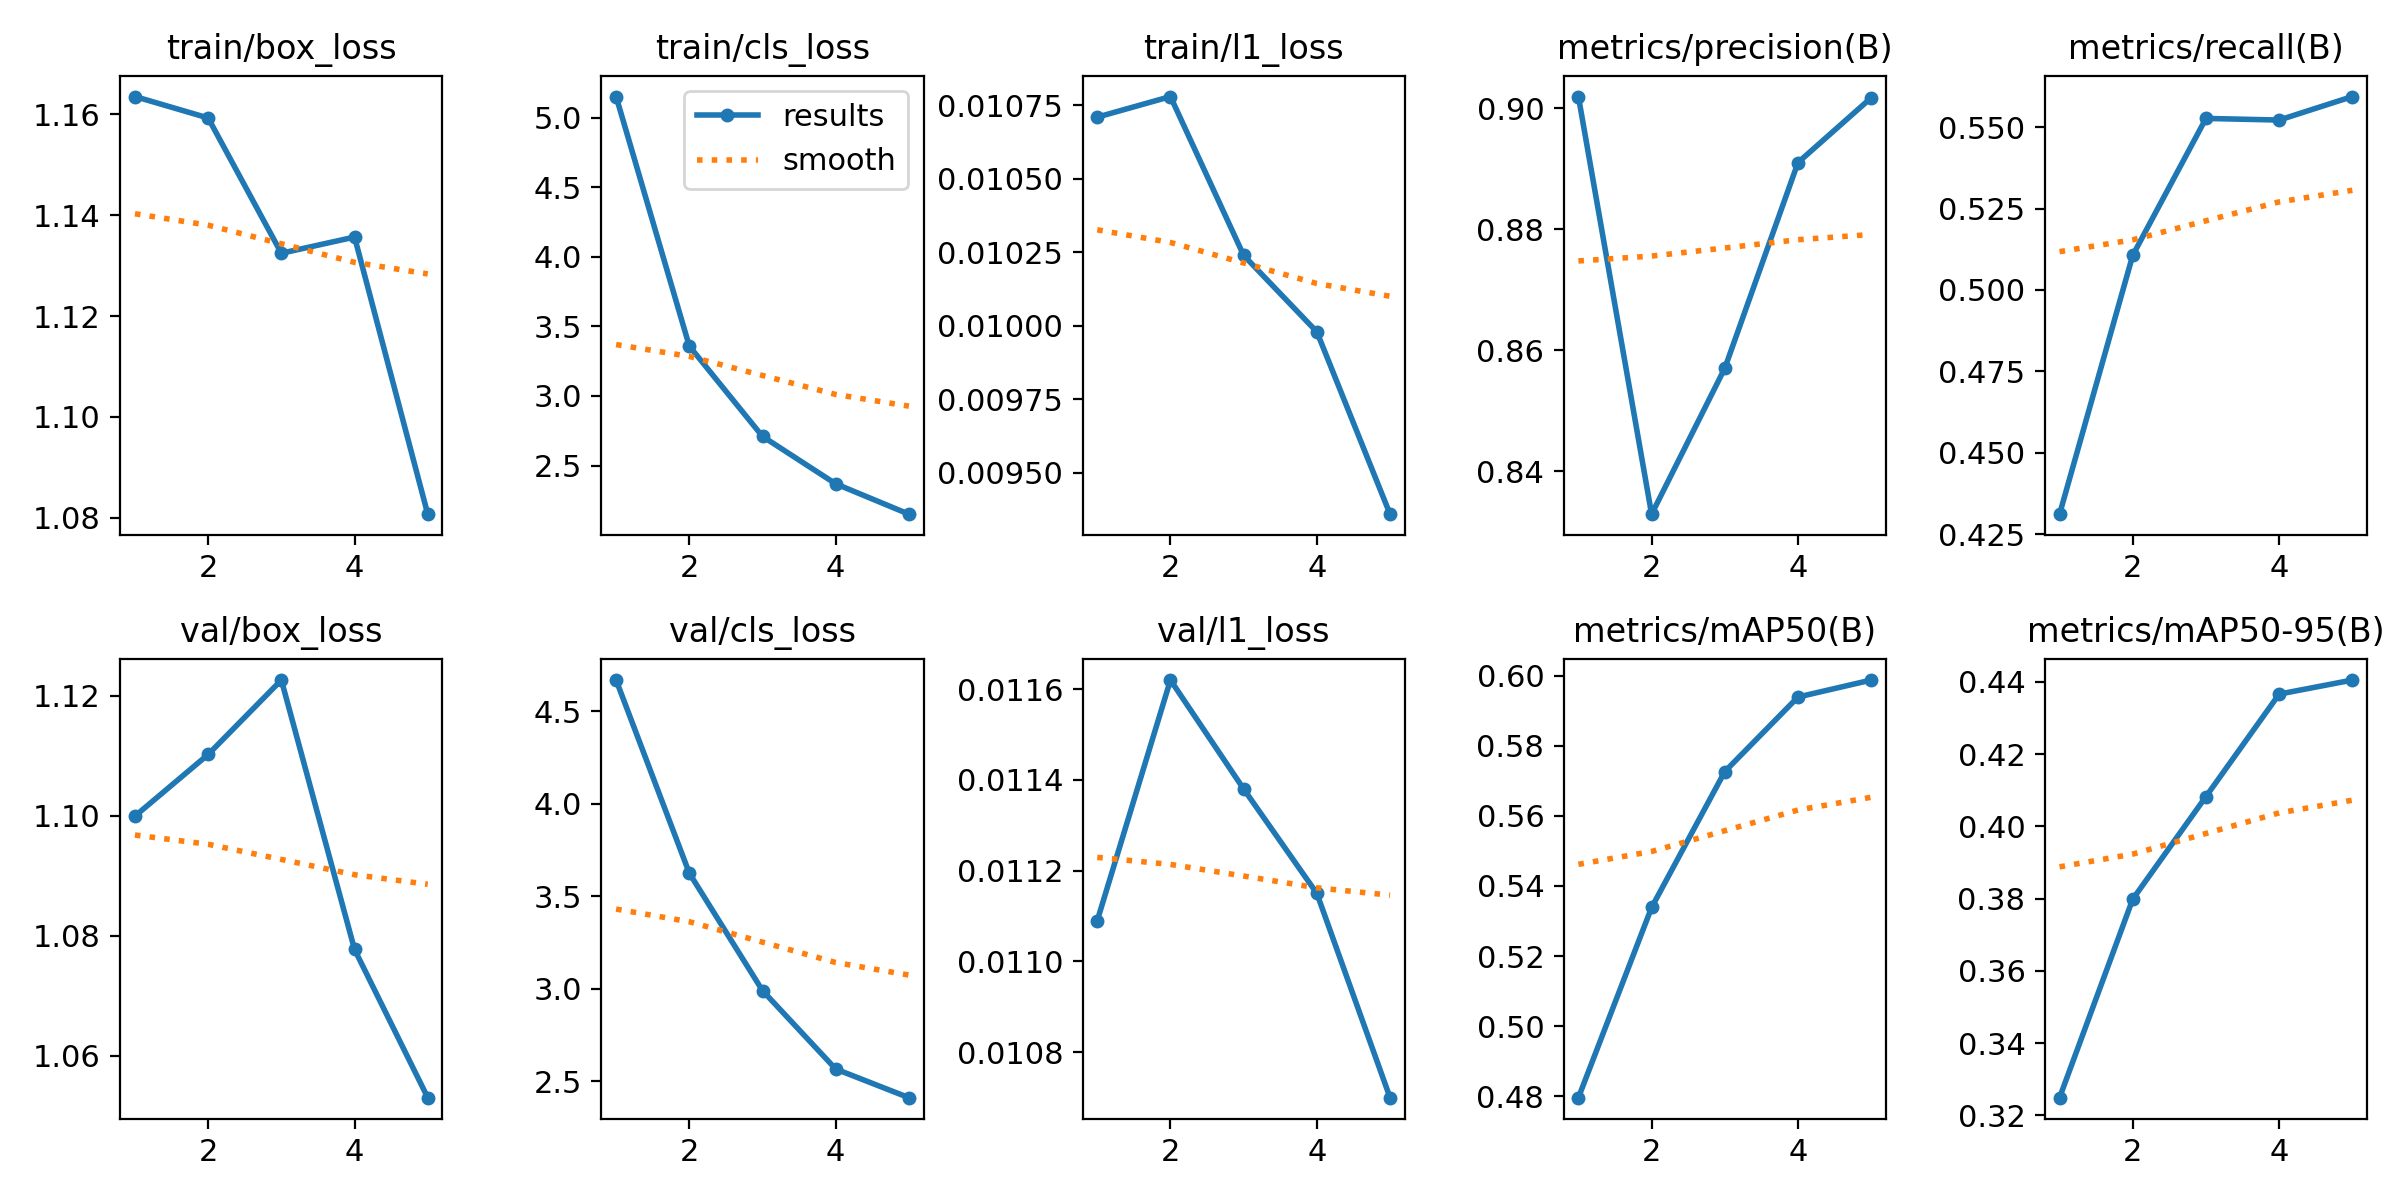

In [12]:
from IPython.display import Image
Image('/content/runs/detect/train/results.png', width=700)

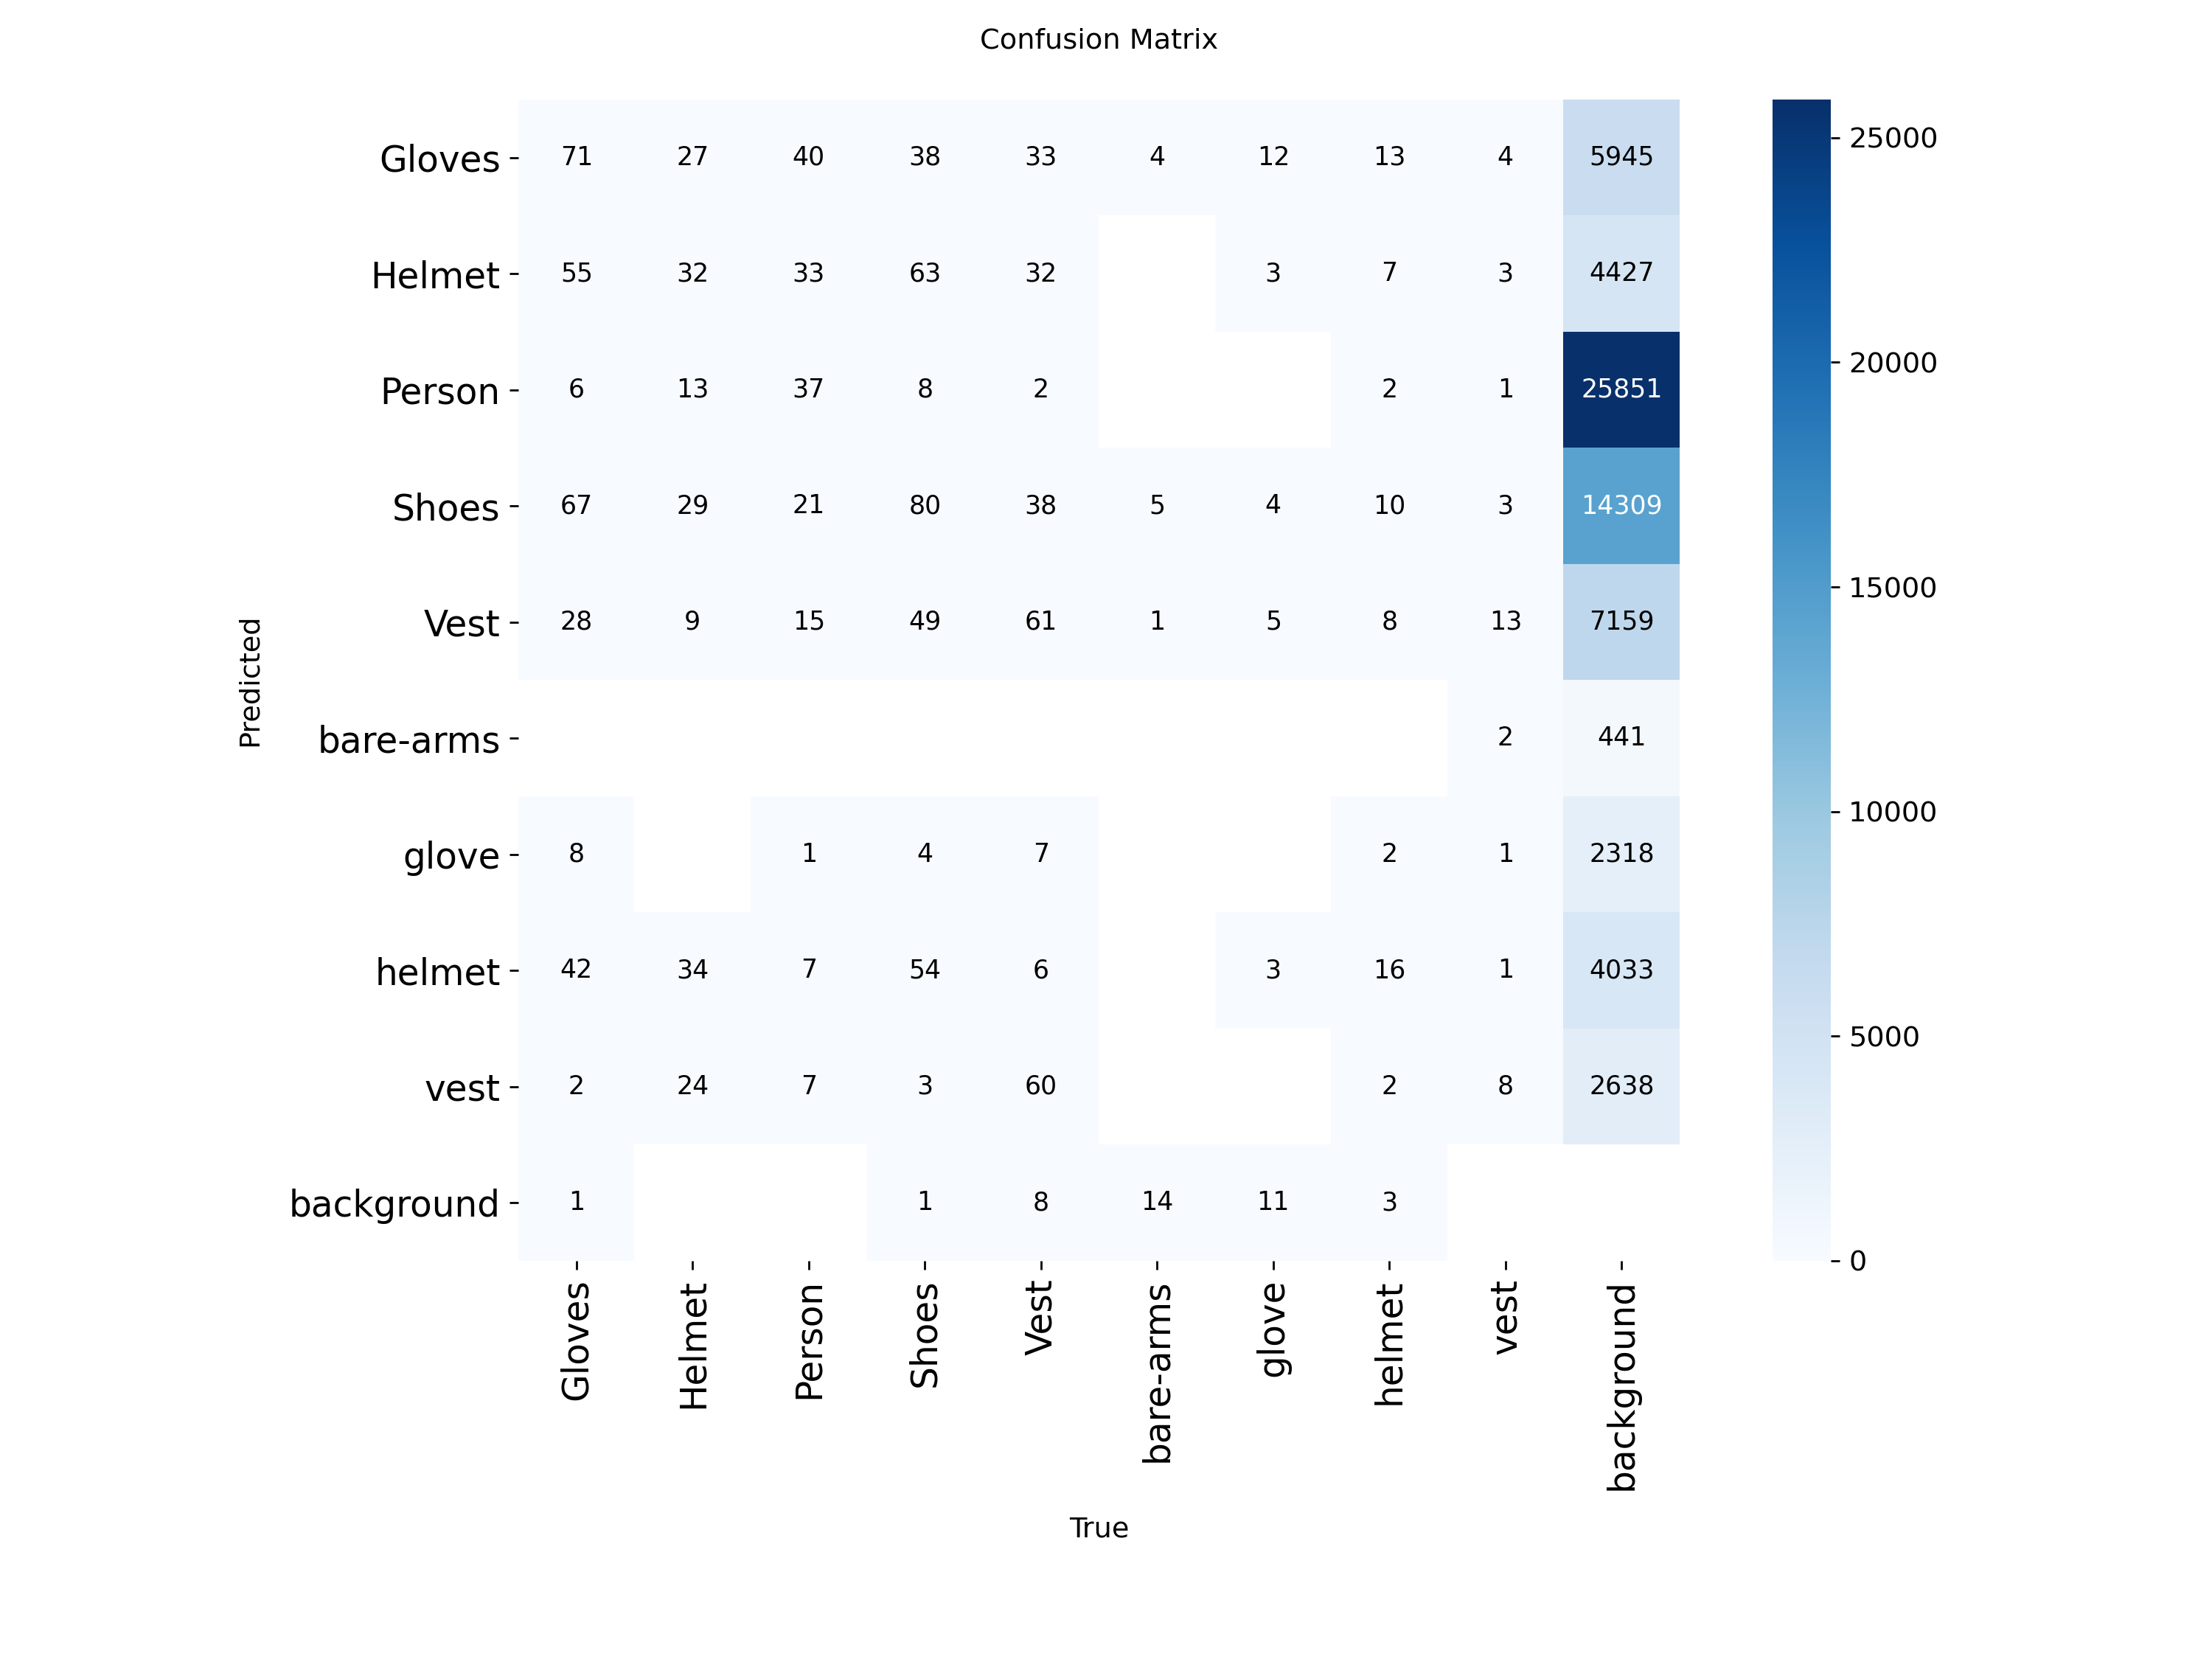

In [16]:
Image('/content/runs/detect/train/confusion_matrix.png', height=450, width=700)

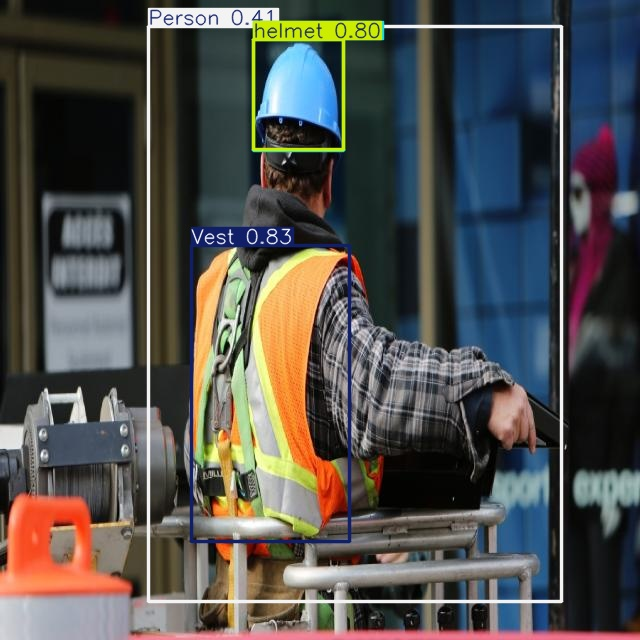

In [28]:
import glob
pred_images = glob.glob('/content/runs/detect/predict/*.jpg')
Image(pred_images[7], height=300, width=400)

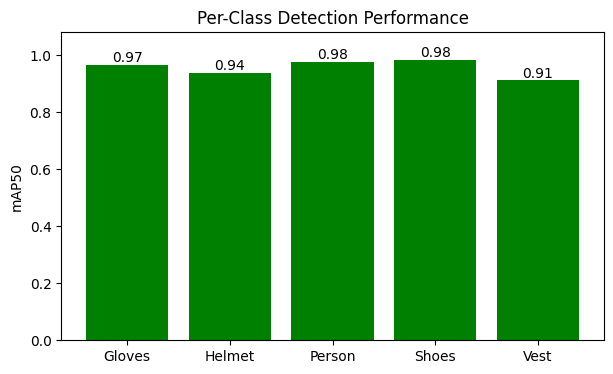

In [29]:
import matplotlib.pyplot as plt

classes = ['Gloves', 'Helmet', 'Person', 'Shoes', 'Vest']
map50 = [0.967, 0.938, 0.977, 0.982, 0.911]

plt.figure(figsize = (7, 4))
bars = plt.bar(classes, map50, color = 'green')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 0.01, f'{height:.2f}', ha = 'center')
plt.ylabel('mAP50')
plt.title('Per-Class Detection Performance')
plt.ylim(0, 1.08)
plt.savefig('/content/per_class_map.png', dpi = 300, bbox_inches = 'tight')
plt.show()